In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()

# Compute average demand per hour per year
avg_by_hour_year = df.groupby(['Year', 'Hour'])['Total Demand'].mean().reset_index()



CSV files loaded


In [8]:
# Start making model for the graph above

# Data Seperation as X and Y

x = df[['Datetime']].copy()
x['Hour'] = x['Datetime'].dt.hour
x = x[['Hour']]  # keep only hour as feature

y = df['Total Demand']

#Data splitting

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)


#print(len(X_train)) # 80% of data size

#print(len(X_test)) # 20% of data size

#print(len(x)) # Original Data size


In [9]:
# Model Building with Random forest

# Training the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Applying the model to make a prediction

y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

plot_df = pd.DataFrame({
    "Hour": X_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

rf_results = pd.DataFrame(["Random forest", rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ["Method", "Training MSE", "Training R2", "Test MSE", "Test R2"]
print(rf_results)


          Method   Training MSE Training R2       Test MSE   Test R2
0  Random forest  516687.014307    0.343202  521190.849665  0.341405


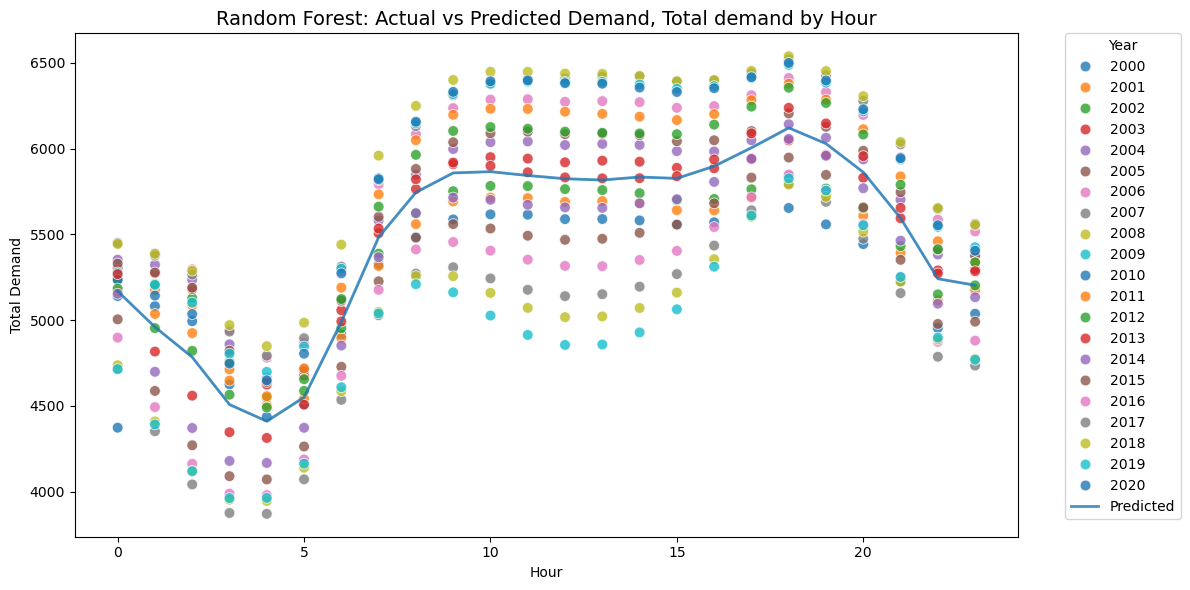

In [12]:
# Model Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build a DataFrame with actual vs predicted
plot_df = pd.DataFrame({
    "Hour": X_test.values.flatten(),
    "Actual_Demand": Y_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

plt.figure(figsize=(12, 6))

# Scatter plot of actual averages
sns.scatterplot(
    data=avg_by_hour_year,
    x="Hour",
    y="Total Demand",
    hue="Year",
    palette="tab10",
    s=60,
    alpha=0.8
)

# Line plot of predicted demand
sns.lineplot(
    data=plot_df,
    x="Hour",
    y="Predicted_Demand",
    linewidth=2,
    alpha=0.8,
    label="Predicted"
)

# Title & labels
plt.title("Random Forest: Actual vs Predicted Demand, Total demand by Hour", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Total Demand")

# ✅ Move legend outside the plot
plt.legend(
    title="Year",
    bbox_to_anchor=(1.05, 1),   # position legend outside
    loc="upper left",           # anchor it to the upper left corner
    borderaxespad=0
)

plt.tight_layout()  # adjust padding so labels/legend don’t get cut
plt.show()
